<a href="https://colab.research.google.com/github/rmilde/econ5200_final_project/blob/main/5200_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [ ]:
!pip install doubleml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
from doubleml import DoubleMLPLR, DoubleMLData
from doubleml.datasets import fetch_401K

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary

Use SCR (Situation – Complication – Resolution) structure. Fill this in LAST, after your analysis is complete.

> **We estimate that [treatment] has an effect of [X] on [outcome] (95% CI: [a, b]).**
>
> **Situation:** ___
> **Complication:** ___
> **Resolution:** ___
>
> **We recommend [action] because [reason].**
>
> **Key assumption that could invalidate this:** ___

---
## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does 401(k) eligibility cause higher net financial assets?
- **Identification strategy:** Double Machine Learning (DML)
- **Key assumption:** Conditional independence — after controlling for income, age, family size, and education, eligibility is as good as random
- **Treatment variable:** p401 (eligible for 401k = 1)
- **Outcome variable:** net_tfa (net total financial assets)
- **Controls:** inc, age, fsize, educ, pira
- **Why prediction alone is insufficient:** A predictive model tells us who tends to have high savings, but not whether making someone eligible would *cause* them to save more. Confounders like income drive both eligibility and savings.

In [ ]:
# --- Data Loading ---
df = fetch_401K(return_type='DataFrame')
print(df.shape)
df.head()

(9915, 14)


,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [ ]:
# --- EDA: Summary Statistics ---
df.describe()

,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
count,9.915000e+03,9.915000e+03,9.915000e+03,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000
mean,1.392864e+04,1.805153e+04,6.381685e+04,41.060212,37200.621094,2.865860,13.206253,0.271004,0.604841,0.380837,0.371357,0.261624,0.242158,0.635199
std,5.490504e+04,6.352259e+04,1.115296e+05,10.344505,24774.251953,1.538937,2.810382,0.444500,0.488909,0.485617,0.483192,0.439541,0.428411,0.481399
min,0.000000e+00,-5.023020e+05,-5.023020e+05,25.000000,-2652.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000e+02,-5.000000e+02,3.291500e+03,32.000000,19413.000000,2.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.635000e+03,1.499000e+03,2.510000e+04,40.000000,31476.000000,3.000000,12.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,8.765500e+03,1.652450e+04,8.148750e+04,48.000000,48583.500000,4.000000,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.430298e+06,1.536798e+06,2.029910e+06,64.000000,242124.000000,13.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# --- EDA: Missing Data ---
df.isnull().sum().sort_values(ascending=False).head(10)

,0
nifa,0
net_tfa,0
tw,0
age,0
inc,0
fsize,0
educ,0
db,0
marr,0
twoearn,0


In [ ]:
df.isnull().sum()

,0
nifa,0
net_tfa,0
tw,0
age,0
inc,0
fsize,0
educ,0
db,0
marr,0
twoearn,0


In [ ]:
# --- EDA: Balance Check (treated vs. untreated) ---
# p401 = eligible for 401k (treatment)
df.groupby('p401')[['net_tfa', 'inc', 'age', 'fsize', 'educ']].mean().T

p401,0,1
net_tfa,10890.477539,38262.058594
inc,32889.800781,49366.976562
age,40.900970,41.509638
fsize,2.848108,2.915960
educ,12.991121,13.813416


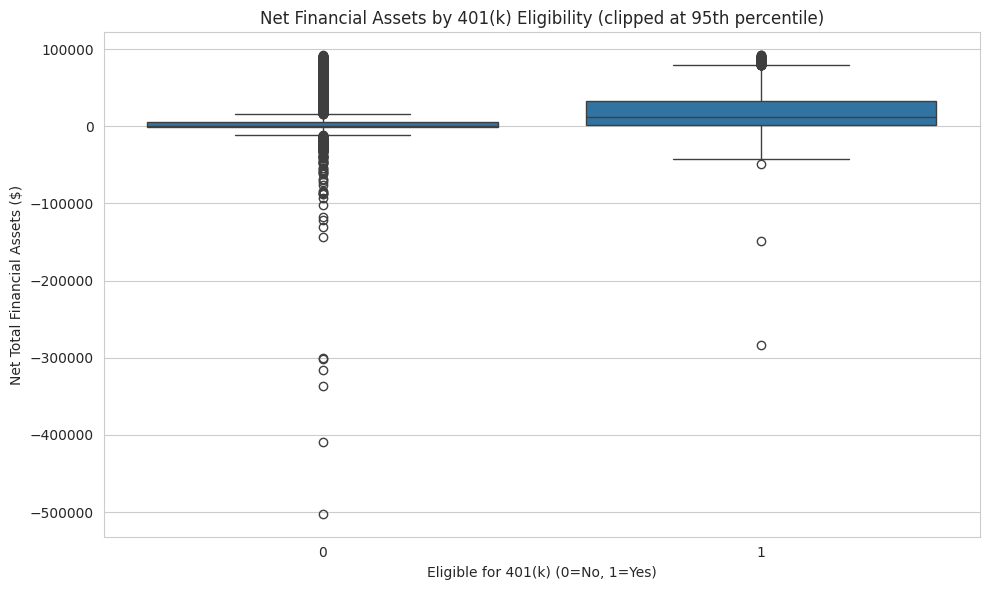

Note: clipped at $91,999 (95th percentile) for readability.
       count          mean           std       min     25%      50%      75%  \
p401                                                                           
0     7321.0  10890.477539  55256.730469 -502302.0 -1184.0    200.0   7399.0   
1     2594.0  38262.058594  79087.515625 -283356.0  3000.0  15249.0  45985.5   

            max  
p401             
0     1462115.0  
1     1536798.0  


In [ ]:
# --- EDA: Treatment-Outcome Visualization ---
fig, ax = plt.subplots()
# Clip to 95th percentile so outliers don't dominate
clip_val = df['net_tfa'].quantile(0.95)
sns.boxplot(data=df[df['net_tfa'] <= clip_val], x='p401', y='net_tfa', ax=ax)
ax.set_title('Net Financial Assets by 401(k) Eligibility (clipped at 95th percentile)')
ax.set_xlabel('Eligible for 401(k) (0=No, 1=Yes)')
ax.set_ylabel('Net Total Financial Assets ($)')
plt.tight_layout()
plt.show()

print(f"Note: clipped at ${clip_val:,.0f} (95th percentile) for readability.")
print(df.groupby('p401')['net_tfa'].describe())

In [ ]:
# Interpretation: The difference in net financial assets between eligible and
# ineligible workers is striking — the median eligible worker holds $15,249
# in financial assets vs. just $200 for the median ineligible worker. However,
# this raw gap cannot be interpreted causally. The ineligible group (p401=0)
# also has far more negative-asset outliers (debt), and as shown in viz 2,
# ineligible workers earn ~$16,500 less on average. The naive gap conflates
# the effect of 401(k) access with pre-existing income differences — which
# is exactly what DML is designed to correct for.

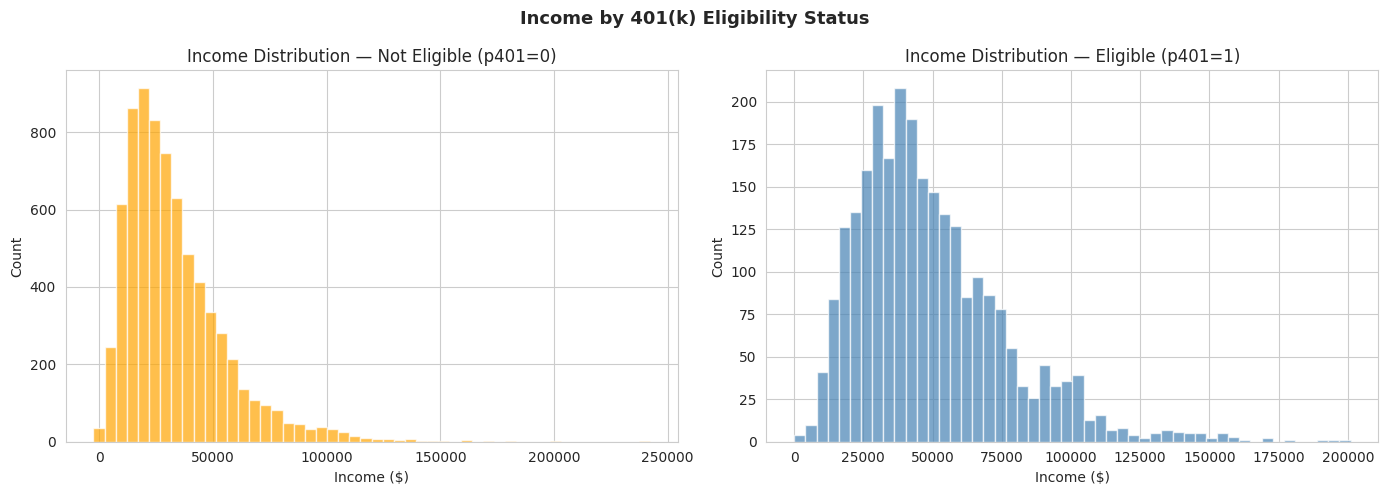

       count          mean           std     min      25%      50%      75%  \
p401                                                                          
0     7321.0  32889.800781  22315.617188 -2652.0  17280.0  27720.0  42828.0   
1     2594.0  49366.976562  27208.443359    60.0  30000.0  43717.5  63322.5   

           max  
p401            
0     242124.0  
1     200997.0  


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate plots for each group so neither gets buried
df[df['p401']==0]['inc'].plot(kind='hist', bins=50, ax=axes[0],
                               color='orange', alpha=0.7, edgecolor='white')
axes[0].set_title('Income Distribution — Not Eligible (p401=0)')
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('Count')

df[df['p401']==1]['inc'].plot(kind='hist', bins=50, ax=axes[1],
                               color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title('Income Distribution — Eligible (p401=1)')
axes[1].set_xlabel('Income ($)')
axes[1].set_ylabel('Count')

plt.suptitle('Income by 401(k) Eligibility Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Also print mean income by group for the balance check
print(df.groupby('p401')['inc'].describe())

In [ ]:
# Interpretation: Eligible workers earn substantially more on average ($49,367 vs $32,890).
# Since income independently drives savings, naive comparisons between groups
# will overstate the causal effect of 401(k) eligibility — higher savings
# among eligible workers partly reflects higher income, not just plan access.
# DML partials out this income-driven selection before estimating the treatment effect.

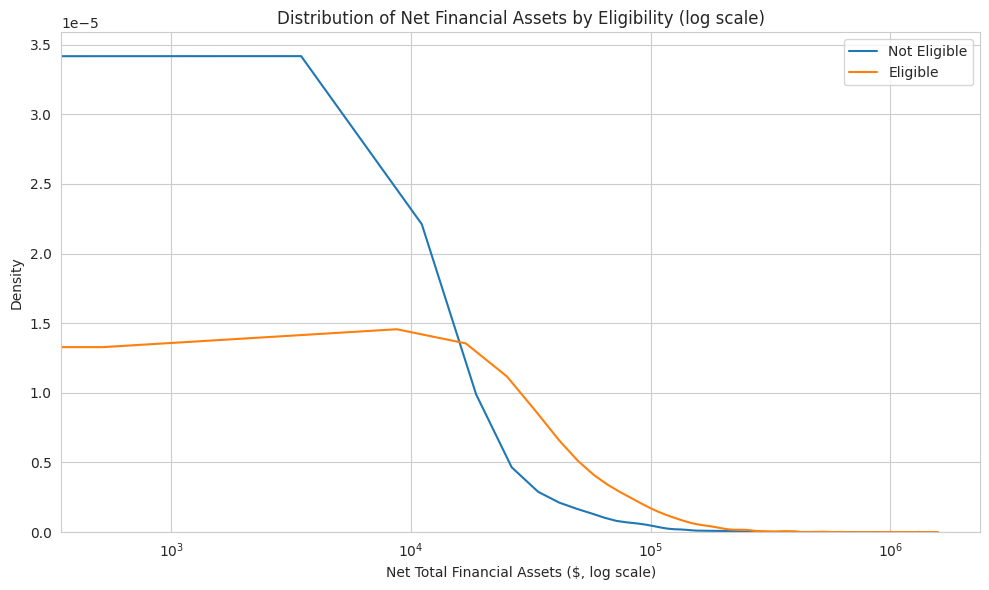

In [ ]:
fig, ax = plt.subplots()
df['net_tfa_pos'] = df['net_tfa'].clip(lower=1)  # log needs positive values
sns.kdeplot(data=df[df['p401']==0], x='net_tfa_pos', label='Not Eligible', ax=ax)
sns.kdeplot(data=df[df['p401']==1], x='net_tfa_pos', label='Eligible', ax=ax)
ax.set_xscale('log')
ax.set_title('Distribution of Net Financial Assets by Eligibility (log scale)')
ax.set_xlabel('Net Total Financial Assets ($, log scale)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Interpretation: The not-eligible group (blue) is heavily concentrated at low
# asset values — the density drops sharply after ~$10,000, meaning most
# ineligible workers hold very little. The eligible group (orange) has a flatter,
# more spread-out distribution with a substantially fatter right tail, indicating
# a meaningful share of eligible workers accumulate $50,000–$500,000+ in assets.
# This shift in the entire distribution (not just the mean) suggests 401(k)
# eligibility is associated with broader wealth-building, though the income
# confounding identified in viz 2 means this gap cannot yet be interpreted causally.

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [ ]:
# --- Naive OLS ---
X_naive = sm.add_constant(df[['p401']])
y = df['net_tfa']
naive_model = sm.OLS(y, X_naive).fit()
print(naive_model.summary())

naive_estimate = naive_model.params['p401']
naive_ci = naive_model.conf_int().loc['p401'].values
print(f'\nNaive estimate: ${naive_estimate:,.0f} (95% CI: [${naive_ci[0]:,.0f}, ${naive_ci[1]:,.0f}])')

                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     368.8
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           9.80e-81
Time:                        17:07:06   Log-Likelihood:            -1.2354e+05
No. Observations:                9915   AIC:                         2.471e+05
Df Residuals:                    9913   BIC:                         2.471e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.089e+04    729.007     14.939      0.0

**Why the naive estimate is biased (upward):**
Higher-income workers are both more likely to be offered 401(k) plans AND
more likely to accumulate financial assets independent of any plan. The naive
OLS absorbs this income-driven selection into the treatment coefficient,
inflating the estimated effect. DML addresses this by partialling out income
(and other confounders) from both the treatment and outcome before estimating
the causal effect.

### 3b. Causal Estimate

In [ ]:
# --- Causal Method: Double Machine Learning (example) ---
from sklearn.ensemble import GradientBoostingRegressor

# Define features
features = ['inc', 'age', 'fsize', 'educ', 'pira', 'incsq']

# Note: incsq = income squared, a common control in this dataset
df['incsq'] = df['inc'] ** 2

# Set up DoubleML data object
dml_data = DoubleMLData(
    df,
    y_col='net_tfa',
    d_cols='p401',
    x_cols=features
)

# Define nuisance models
ml_g = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
ml_m = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)

# Fit DML
dml_model = DoubleMLPLR(dml_data, ml_l=ml_g, ml_m=ml_m, n_folds=5)
dml_model.fit()
print(dml_model.summary)

              coef      std err         t         P>|t|         2.5 %  \
p401  14440.854926  1567.324745  9.213697  3.150824e-20  11368.954874   

            97.5 %  
p401  17512.754978  


### 3c. Prediction Model (for comparison)

In [ ]:
# --- Predictive Model (NOT causal — for comparison only) ---
# from sklearn.metrics import r2_score, mean_squared_error
#
# all_features = ['your_treatment', 'control_1', 'control_2', 'confounder_1']
# rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
# y_pred = cross_val_predict(rf, df[all_features], df['your_outcome'], cv=5)
#
# print(f'Prediction R²: {r2_score(df["your_outcome"], y_pred):.3f}')
# print(f'Prediction RMSE: {np.sqrt(mean_squared_error(df["your_outcome"], y_pred)):.3f}')
# print('\nNote: This tells us how well we can PREDICT the outcome,')
# print('but NOT how the treatment CAUSES changes in the outcome.')

### 3d. Compare Naive vs. Causal

> The naive estimate is [X], the causal estimate is [Y]. The difference of [Z] is attributable to [confounding/selection bias].

In [ ]:
# --- Comparison Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
#
# estimates = ['Naive OLS', 'Causal (DML)']
# points = [naive_estimate, causal_estimate]
# ci_lower = [naive_ci[0], causal_ci[0]]
# ci_upper = [naive_ci[1], causal_ci[1]]
# errors = [[p - l for p, l in zip(points, ci_lower)],
#           [u - p for p, u in zip(points, ci_upper)]]
#
# ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
#             markersize=10, linewidth=2, color='#1a237e')
# ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# ax.set_ylabel('Estimated Effect')
# ax.set_title('Naive vs. Causal Estimate')
# plt.tight_layout()
# plt.show()

### 3e. Robustness Check

In [ ]:
# --- Robustness: Different nuisance model ---
# dml_robust = LinearDML(
#     model_y=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml_robust.fit(Y, T, X=X, W=W)
# robust_ate = dml_robust.ate(X)
# robust_ci = dml_robust.ate_interval(X, alpha=0.05)
# print(f'Robustness ATE (RF nuisance): {robust_ate:.4f}')
# print(f'95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}]')

---
## Part 4: Threats to Identification

**Minimum 500 words. Be honest — this is where you demonstrate critical thinking.**

### 1. Most Serious Threat

- **Threat:** ___
- **Direction of bias:** [Does this make my estimate too large or too small?]
- **What would address it:** [Ideal data, instrument, or design]

### 2. Second Threat

- **Threat:** ___
- **Why it matters:** ___
- **Partial mitigation:** [What I did or could do]

### 3. What I Cannot Rule Out

[Be honest about what remains. This limitation means my estimate should be interpreted as ___ rather than a definitive causal effect.]

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [ ]:
# Save this as app.py in your project repo

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Consulting Report Dashboard", layout="wide")
st.title("Consulting Report: [Your Title]")

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

treatment_multiplier = st.sidebar.slider(
    "Treatment intensity multiplier",
    min_value=0.5, max_value=3.0, value=1.0, step=0.1
)

# TODO: Add more sliders for your specific parameters
# control_level = st.sidebar.selectbox("Control scenario", ["Low", "Medium", "High"])

# --- Load your fitted model or pre-computed results ---
# Option 1: Load a pickled model
# import joblib
# model = joblib.load("fitted_model.pkl")

# Option 2: Use pre-computed coefficients
baseline_ate = 0.0    # TODO: Replace with your causal estimate
baseline_se = 0.0     # TODO: Replace with your standard error

# --- Compute What-If Estimate ---
adjusted_ate = baseline_ate * treatment_multiplier
adjusted_se = baseline_se * treatment_multiplier
ci_lower = adjusted_ate - 1.96 * adjusted_se
ci_upper = adjusted_ate + 1.96 * adjusted_se

# --- Display Results ---
col1, col2, col3 = st.columns(3)
col1.metric("Estimated Effect", f"{adjusted_ate:.3f}")
col2.metric("95% CI Lower", f"{ci_lower:.3f}")
col3.metric("95% CI Upper", f"{ci_upper:.3f}")

st.markdown(f"""
> **What-if interpretation:** If treatment intensity is multiplied by
> {treatment_multiplier:.1f}x, the estimated effect changes to
> {adjusted_ate:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]).
""")

# --- Uncertainty Visualization ---
multipliers = np.arange(0.5, 3.1, 0.1)
ates = baseline_ate * multipliers
ses = baseline_se * multipliers

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=multipliers, y=ates + 1.96 * ses,
    mode="lines", line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates - 1.96 * ses,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.2)", name="95% CI"
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig.add_vline(x=treatment_multiplier, line_dash="dash", line_color="red",
              annotation_text=f"Current: {treatment_multiplier:.1f}x")
fig.update_layout(
    title="What-If: Effect vs. Treatment Intensity",
    xaxis_title="Treatment Intensity Multiplier",
    yaxis_title="Estimated Causal Effect",
    template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)

# --- Counterfactual Scenario ---
st.subheader("Counterfactual: What if treatment intensity doubled?")
counterfactual_ate = baseline_ate * 2.0
counterfactual_ci = (counterfactual_ate - 1.96 * baseline_se * 2.0,
                     counterfactual_ate + 1.96 * baseline_se * 2.0)
st.write(f"If treatment intensity doubled, the estimated effect would be "
         f"**{counterfactual_ate:.3f}** (95% CI: [{counterfactual_ci[0]:.3f}, {counterfactual_ci[1]:.3f}]).")
'''

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
# print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')

---
## Part 6: Presentation Script

**5 minutes total. Practice with a timer.**

| Segment | Time | Your Script |
|---------|------|-------------|
| **Hook** | 30s | ___ |
| **Problem** | 60s | ___ |
| **Method** | 60s | ___ |
| **Finding** | 60s | ___ |
| **Recommendation** | 60s | ___ |
| **Defense** | 30s | ___ |

### Adversarial Prep

| Question Category | Your Prepared Answer |
|-------------------|---------------------|
| "How do you know this is causal?" | ___ |
| "Why this model?" | ___ |
| "Would this generalize?" | ___ |
| "Is the effect large enough?" | ___ |

---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

Document at least 3 significant AI interactions.

### Entry 1: [Task — e.g., Code Generation]

- **Prompt:** [What you asked the AI]
- **Response:** [Summary of what the AI produced]
- **Iterate:** [What you changed or asked to refine]
- **Modify:** [How you adapted the output for your specific use case]
- **Evaluate:** [How you verified correctness — tests run, sources checked, logic reviewed]

### Entry 2: [Task — e.g., Analysis Assistance]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___

### Entry 3: [Task — e.g., Writing / Literature Review]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___